# Codebase for Pattern Recognition and Data Mining CSEN 281
Executed by: Manav Pragnesh Vakharia

SCU ID: 07700023383

Email: mvakharia@scu.edu

In [ ]:
!pip install pydub
!pip install tensorflow

In [2]:
import pyspark
import pandas as pd
import numpy as np
import librosa as lb
import soundfile as sf
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import os
import matplotlib.pyplot as plt
import scipy.stats
from tqdm import tqdm

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Splitting audio files into 2 parts

In [ ]:
from pydub import AudioSegment
import os
import shutil

# Function to segment audio files into 15-second clips
def segment_audio(input_folder, output_folder):
    genres = os.listdir(input_folder)
    for g in genres:
        genre_path = os.path.join(input_folder, g)
        genre_output_path = os.path.join(output_folder, g)
        if not os.path.exists(genre_output_path):
            os.makedirs(genre_output_path)

        for j, filename in enumerate(os.listdir(genre_path), start=1):
            song_path = os.path.join(genre_path, filename)
            audio = AudioSegment.from_wav(song_path)

            for w in range(0, 2):  # 2 segments of 15 seconds each for 30-second clips
                t1 = 15 * w * 1000
                t2 = 15 * (w + 1) * 1000
                segment = audio[t1:t2]
                segment.export(os.path.join(genre_output_path, f'{g}{j}_{w}.wav'), format="wav")

# Define folders
input_folder = "/content/drive/MyDrive/Genre-prediction/Data/genres_original/"
output_folder = "/content/drive/MyDrive/Genre-prediction/Data/genres_original_split/"

# Call the function to split audio
segment_audio(input_folder, output_folder)

Extracting all the file locations

In [5]:
root = "/content/drive/MyDrive/Genre-prediction/Data/genres_original_split/"
genres = os.listdir(root)
loc_dict = {}
for i in range(len(genres)):
  loc_dict[genres[i]] = [root + genres[i] + "/" + s for s in os.listdir(root+genres[i])]
for i in range(len(genres)):
  loc_dict[genres[i]] = np.sort(loc_dict[genres[i]])

## Plotting Feature Graphs for all the Genres for comparison purposes

In [ ]:
import librosa as lb
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import os

output_dir = "/content/drive/MyDrive/Genre-prediction/Data/feature_graphs/"
os.makedirs(output_dir, exist_ok=True)

def plot_feature_across_genres(feature_name, loc_dict):
    plt.figure(figsize=(15, 10), facecolor='white')
    total_genres = len(loc_dict)
    for i, (genre, song_locations) in tqdm(enumerate(loc_dict.items())):
        y, sr = lb.load(song_locations[0])
        plt.subplot((total_genres + 1) // 2, 2, i + 1)
        plt.title(f'{genre}')

        if feature_name == 'melspectrogramFeature':
            feature = lb.feature.melspectrogram(y=y, sr=sr)
            lb.display.specshow(lb.power_to_db(feature, ref=np.max))
        elif feature_name == 'chromaCqt':
            feature = lb.feature.chroma_cqt(y=y, sr=sr)
            lb.display.specshow(feature)
        elif feature_name == 'chromaCens':
            feature = lb.feature.chroma_cens(y=y, sr=sr)
            lb.display.specshow(feature)
        elif feature_name == 'chromaStft':
            feature = lb.feature.chroma_stft(y=y, sr=sr)
            lb.display.specshow(feature)
        elif feature_name == 'spectralCentroid':
            feature = lb.feature.spectral_centroid(y=y, sr=sr)[0]
            plt.ylim(0,8000)
            plt.plot(lb.times_like(feature), feature)
        elif feature_name == 'spectralBandwidth':
            feature = lb.feature.spectral_bandwidth(y=y, sr=sr)[0]
            plt.ylim(0,4000)
            plt.plot(lb.times_like(feature), feature)
        elif feature_name == 'spectralRolloff':
            feature = lb.feature.spectral_rolloff(y=y, sr=sr)[0]
            plt.ylim(0,10000)
            plt.plot(lb.times_like(feature), feature)
        elif feature_name == 'rms':
            feature = lb.feature.rms(y=y)[0]
            plt.ylim(0,0.4)
            plt.plot(lb.times_like(feature), feature)
        elif feature_name == 'tonnetz':
            feature = lb.feature.tonnetz(y=lb.effects.harmonic(y), sr=sr)
            lb.display.specshow(feature)
        else:
            continue

    plt.suptitle(f'{feature_name} across Genres')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f'{feature_name}.png'))
    plt.close()

features = [
    'melspectrogramFeature', 'chromaCqt', 'chromaCens', 'chromaStft',
    'spectralCentroid', 'spectralBandwidth', 'spectralRolloff',
    'rms', 'tonnetz'
]

for feature in features:
    plot_feature_across_genres(feature, loc_dict)

# Generating dataframe for data processing

In [ ]:
n_mfccs = 20
n_mels = 8
n_chroma = 12

def mfccFeature(y, sr):
    mfcc_feature = lb.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfccs)
    mfcc_stats = []
    for mfcc in mfcc_feature:
      mfcc_stats.append(np.mean(mfcc))
      mfcc_stats.append(np.var(mfcc))
    return mfcc_stats

def melspectrogramFeature(y, sr):
    fmax = min(8000, sr / 2)
    melspec = lb.feature.melspectrogram(y=y, sr=sr*10, n_mels=n_mels, fmax=100000, n_fft=128)
    melspec_stats = []
    for mels in melspec:
      melspec_stats.append(np.mean(mels))
      melspec_stats.append(np.var(mels))
    return melspec_stats

def chromaCqt(y, sr):
    cqt = lb.feature.chroma_cqt(y=y, sr=sr, n_chroma=n_chroma, hop_length=256, bins_per_octave=24)
    cqtStats = []
    for cqtarr in cqt:
      cqtStats.append(np.mean(cqtarr))
      cqtStats.append(np.var(cqtarr))
    return cqtStats

def chromaCens(y, sr):
    cens = lb.feature.chroma_cens(y=y, sr=sr, n_chroma=n_chroma, hop_length=256, bins_per_octave=24)
    censStats = []
    for censarr in cens:
      censStats.append(np.mean(censarr))
      censStats.append(np.var(censarr))
    return censStats

def chromaStft(y, sr):
    stft = lb.feature.chroma_stft(y=y, sr=sr, n_fft=128, n_chroma=n_chroma)
    stftStats = []
    for stftarr in stft:
      stftStats.append(np.mean(stftarr))
      stftStats.append(np.var(stftarr))
    return stftStats

def spectralCentroid(y, sr):
    specCentroid = lb.feature.spectral_centroid(y=y, sr=sr, n_fft=128)
    return [np.mean(specCentroid[0]),np.var(specCentroid[0])]

def spectralBandwidth(y, sr):
    specBandwidth = lb.feature.spectral_bandwidth(y=y, sr=sr, n_fft=128)
    return [np.mean(specBandwidth[0]),np.var(specBandwidth[0])]

def spectralFlatness(y, sr):
    specflatness = lb.feature.spectral_flatness(y=y, n_fft=128)
    return [np.mean(specflatness[0]), np.var(specflatness[0])]

def spectralRolloff(y, sr):
    specRolloff = lb.feature.spectral_rolloff(y=y, sr=sr, roll_percent=0.85, n_fft=128, hop_length=256)
    return [np.mean(specRolloff[0]),np.var(specRolloff[0])]

def rmsFeature(y):
    rms = lb.feature.rms(y=y)
    return [np.mean(rms[0]),np.var(rms[0])]

def tonnetzFeature(y, sr):
    tonnetz = lb.feature.tonnetz(y=y, sr=sr)
    tonnetzStats = []
    for tonnetzarr in tonnetz:
      tonnetzStats.append(np.mean(tonnetzarr))
      tonnetzStats.append(np.var(tonnetzarr))
    return tonnetzStats

def tempoFeature(y, sr):
    prior = scipy.stats.lognorm(s=1.0, scale=120)
    onset_env = lb.onset.onset_strength(y=y, sr=sr)
    tempo = lb.feature.tempo(onset_envelope=onset_env, sr=sr, prior=prior)
    return tempo[0]

def zcr(y):
    zcr = lb.feature.zero_crossing_rate(y)
    return [np.mean(zcr[0]),np.var(zcr[0])]

def getHarmonic(y):
    harm = lb.effects.harmonic(y)
    return [np.mean(harm), np.var(harm)]

In [ ]:
mfccColumn = []
for i in range(n_mfccs):
  mfccColumn.append("mfccFeatureMean_"+str(i+1))
  mfccColumn.append("mfccFeatureVar_"+str(i+1))

melColumn = []
for i in range(n_mels):
  melColumn.append("melspectrogramMean_"+str(i+1))
  melColumn.append("melspectrogramVar_"+str(i+1))

chromacqtColumn = []
for i in range(n_chroma):
  chromacqtColumn.append("chromaCQTMean_"+str(i+1))
  chromacqtColumn.append("chromaCQTVar_"+str(i+1))


chromaCENSColumn = []
for i in range(n_chroma):
  chromaCENSColumn.append("chromaCENSMean_"+str(i+1))
  chromaCENSColumn.append("chromaCENSVar_"+str(i+1))


chromastftColumn = []
for i in range(n_chroma):
  chromastftColumn.append("chromaSTFTMean_"+str(i+1))
  chromastftColumn.append("chromaSTFTVar_"+str(i+1))

tonnetzColumn = []
for i in range(6):
  tonnetzColumn.append("tonnetzMean_"+str(i+1))
  tonnetzColumn.append("tonnetzVar_"+str(i+1))

,location,genre,mfccFeatureMean_1,mfccFeatureVar_1,mfccFeatureMean_2,mfccFeatureVar_2,mfccFeatureMean_3,mfccFeatureVar_3,mfccFeatureMean_4,mfccFeatureVar_4,...,tonnetzVar_4,tonnetzMean_5,tonnetzVar_5,tonnetzMean_6,tonnetzVar_6,tempoValue,zcrMean,zcrVar,harmonicMean,HarmonicVar


In [ ]:
cols = ["location", "genre"] +  mfccColumn + melColumn + chromacqtColumn + chromaCENSColumn + chromastftColumn + ["spectralCentroidMean", "spectralCentroidVar", "spectralBandwidthMean", "spectralBandwidthVar", "spectralFlatnessMean", "spectralFlatnessVar", "spectralRolloffMean", "spectralRolloffVar", "rmsMean", "rmsVar"]+ tonnetzColumn + ["tempoValue", "zcrMean", "zcrVar", "harmonicMean", "HarmonicVar"]
df = pd.DataFrame(columns = cols)
df

In [ ]:
for i in genres:
  for j in tqdm(loc_dict[i]):
    try:
      y, sr = lb.load(j)
      mfccValues = mfccFeature(y, sr)
      melspecValues = melspectrogramFeature(y, sr)
      cqtValues = chromaCqt(y, sr)
      censValues = chromaCens(y, sr)
      stftValues = chromaStft(y, sr)
      specCentValue = spectralCentroid(y, sr)
      specBandValue = spectralBandwidth(y, sr)
      specFlatValue = spectralFlatness(y, sr)
      specRollValue = spectralRolloff(y, sr)
      rmsValue = rmsFeature(y)
      tonnetzValues = tonnetzFeature(y, sr)
      tempoValue = tempoFeature(y, sr)
      zcrValues = zcr(y)
      harmonicValues = getHarmonic(y)
      df.loc[len(df)] = [j, i] + mfccValues + melspecValues + cqtValues + censValues + stftValues + specCentValue + specBandValue + specFlatValue + specRollValue + rmsValue + tonnetzValues + [tempoValue] + zcrValues + harmonicValues

    except FileNotFoundError:
        print(f"Warning: File not found - {j}")
        continue
    except lb.util.exceptions.ParameterError:
        print(f"Warning: Format not recognized or file corrupted - {j}")
        continue
    except Exception as e:
        print(f"Warning: An error occurred with file {j} - {str(e)}")
        continue

100%|██████████| 200/200 [06:08<00:00,  1.84s/it]


In [ ]:
df.to_pickle("/content/drive/MyDrive/Genre-prediction/Data/dataframe_final.pkl")

In [17]:
import pandas as pd
import numpy as np
import librosa as lb
import soundfile as sf
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import os
import matplotlib.pyplot as plt
import scipy.stats
from tqdm import tqdm

Extracting all the file locations

In [84]:
root = "/content/drive/MyDrive/Genre-prediction/Data/genres_original/"
genres = os.listdir(root)
loc_dict = {}
for i in range(len(genres)):
  loc_dict[genres[i]] = [root + genres[i] + "/" + s for s in os.listdir(root+genres[i])]
for i in range(len(genres)):
  loc_dict[genres[i]] = np.sort(loc_dict[genres[i]])

In [85]:
df = pd.read_pickle("/content/drive/MyDrive/Genre-prediction/Data/dataframe_final.pkl")

In [103]:
df

,location,genre,mfccFeatureMean_1,mfccFeatureVar_1,mfccFeatureMean_2,mfccFeatureVar_2,mfccFeatureMean_3,mfccFeatureVar_3,mfccFeatureMean_4,mfccFeatureVar_4,...,tonnetzMean_5,tonnetzVar_5,tonnetzMean_6,tonnetzVar_6,tempoValue,zcrMean,zcrVar,harmonicMean,HarmonicVar,genre_mapping
0,/content/drive/MyDrive/Genre-prediction/Data/g...,disco,-116.264465,1455.241089,114.204468,621.012695,-21.091326,198.876480,36.450897,217.725616,...,0.012164,0.000688,0.015613,0.000698,52.734375,0.085077,0.003012,-0.000002,0.006946,0
1,/content/drive/MyDrive/Genre-prediction/Data/g...,disco,-84.655190,1002.620056,106.235634,390.942566,-32.578197,242.423523,37.570892,140.652939,...,-0.004040,0.000680,-0.000547,0.000747,52.734375,0.115248,0.001535,-0.000011,0.006240,0
2,/content/drive/MyDrive/Genre-prediction/Data/g...,disco,-55.731377,2155.362549,67.131203,545.523743,-15.408356,338.905853,22.065889,196.671219,...,0.004478,0.001205,0.015196,0.001072,56.173573,0.132340,0.003724,-0.000395,0.014403,0
3,/content/drive/MyDrive/Genre-prediction/Data/g...,disco,-59.674374,2524.842529,69.634132,798.135193,-15.073498,420.800781,24.759365,266.493805,...,0.011809,0.000729,0.009158,0.000702,56.173573,0.130955,0.004014,-0.000404,0.014084,0
4,/content/drive/MyDrive/Genre-prediction/Data/g...,disco,-82.088844,3912.935791,70.159210,508.247375,13.850916,404.800537,3.309768,450.480652,...,-0.004191,0.000734,-0.013129,0.000471,61.523438,0.141631,0.003063,-0.000005,0.006804,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1993,/content/drive/MyDrive/Genre-prediction/Data/g...,pop,-129.161209,5588.315918,48.150597,1160.343872,32.873543,1243.518188,11.383502,544.302551,...,0.012561,0.001324,-0.024716,0.000694,49.692007,0.141038,0.020824,-0.000935,0.043995,9
1994,/content/drive/MyDrive/Genre-prediction/Data/g...,pop,-30.503078,3383.396240,53.915035,608.194397,14.767110,382.463348,18.092840,197.920654,...,0.002888,0.000312,-0.005525,0.000514,54.978391,0.154127,0.007337,0.000018,0.023389,9
1995,/content/drive/MyDrive/Genre-prediction/Data/g...,pop,-21.445375,2954.259766,67.843506,812.572937,-2.608770,828.449280,17.342857,262.053528,...,0.021401,0.005245,-0.011715,0.001155,54.978391,0.136243,0.004630,-0.000037,0.031635,9
1996,/content/drive/MyDrive/Genre-prediction/Data/g...,pop,-187.715057,5423.670410,88.825760,835.732605,56.079414,588.272034,34.321747,289.928101,...,0.034561,0.021143,-0.059513,0.003403,71.777344,0.042001,0.001114,0.000022,0.019573,9


In [86]:
df.head()

,location,genre,mfccFeatureMean_1,mfccFeatureVar_1,mfccFeatureMean_2,mfccFeatureVar_2,mfccFeatureMean_3,mfccFeatureVar_3,mfccFeatureMean_4,mfccFeatureVar_4,...,tonnetzVar_4,tonnetzMean_5,tonnetzVar_5,tonnetzMean_6,tonnetzVar_6,tempoValue,zcrMean,zcrVar,harmonicMean,HarmonicVar
0,/content/drive/MyDrive/Genre-prediction/Data/g...,disco,-116.264465,1455.241089,114.204468,621.012695,-21.091326,198.876480,36.450897,217.725616,...,0.007562,0.012164,0.000688,0.015613,0.000698,52.734375,0.085077,0.003012,-0.000002,0.006946
1,/content/drive/MyDrive/Genre-prediction/Data/g...,disco,-84.655190,1002.620056,106.235634,390.942566,-32.578197,242.423523,37.570892,140.652939,...,0.007347,-0.004040,0.000680,-0.000547,0.000747,52.734375,0.115248,0.001535,-0.000011,0.006240
2,/content/drive/MyDrive/Genre-prediction/Data/g...,disco,-55.731377,2155.362549,67.131203,545.523743,-15.408356,338.905853,22.065889,196.671219,...,0.007611,0.004478,0.001205,0.015196,0.001072,56.173573,0.132340,0.003724,-0.000395,0.014403
3,/content/drive/MyDrive/Genre-prediction/Data/g...,disco,-59.674374,2524.842529,69.634132,798.135193,-15.073498,420.800781,24.759365,266.493805,...,0.004823,0.011809,0.000729,0.009158,0.000702,56.173573,0.130955,0.004014,-0.000404,0.014084
4,/content/drive/MyDrive/Genre-prediction/Data/g...,disco,-82.088844,3912.935791,70.159210,508.247375,13.850916,404.800537,3.309768,450.480652,...,0.005644,-0.004191,0.000734,-0.013129,0.000471,61.523438,0.141631,0.003063,-0.000005,0.006804


In [102]:
df.describe()

,mfccFeatureMean_1,mfccFeatureVar_1,mfccFeatureMean_2,mfccFeatureVar_2,mfccFeatureMean_3,mfccFeatureVar_3,mfccFeatureMean_4,mfccFeatureVar_4,mfccFeatureMean_5,mfccFeatureVar_5,...,tonnetzMean_5,tonnetzVar_5,tonnetzMean_6,tonnetzVar_6,tempoValue,zcrMean,zcrVar,harmonicMean,HarmonicVar,genre_mapping
count,1998.000000,1998.000000,1998.000000,1998.000000,1998.000000,1998.000000,1998.000000,1998.000000,1998.000000,1998.000000,...,1998.000000,1998.000000,1998.000000,1998.000000,1998.000000,1998.000000,1998.000000,1998.000000,1998.000000,1998.000000
mean,-144.862152,3444.870361,99.956421,679.020264,-9.276597,442.759247,36.596607,212.576431,-1.407851,167.231903,...,0.000663,0.002743,-0.000497,0.002756,58.375796,0.103595,0.002903,-0.000366,0.012543,4.500501
std,102.408905,2685.039307,32.268604,450.404022,22.318270,291.041412,16.887352,120.868340,12.553603,103.892822,...,0.019846,0.003144,0.021084,0.003182,9.265732,0.042807,0.003163,0.001690,0.011899,2.874394
min,-586.144714,70.583244,-3.103312,23.263685,-93.377266,5.596845,-22.050549,3.916000,-39.808701,23.776579,...,-0.090387,0.000028,-0.096790,0.000018,35.397046,0.021121,0.000038,-0.026058,0.000014,0.000000
25%,-202.064663,1654.821442,76.583445,363.084076,-24.750036,242.557762,24.671288,119.951099,-10.425954,92.980247,...,-0.008445,0.000771,-0.011275,0.000811,51.679688,0.069784,0.000949,-0.000093,0.004363,2.000000
50%,-120.457130,2847.887329,98.242805,578.784668,-11.139131,372.353867,37.361734,187.604172,-0.563109,143.020363,...,0.001494,0.001555,-0.000728,0.001584,57.421875,0.099517,0.001862,-0.000006,0.008792,5.000000
75%,-70.948122,4578.892090,120.564629,856.602081,5.520123,568.033417,48.664763,277.435234,7.808733,218.313251,...,0.011424,0.003602,0.010461,0.003525,64.599609,0.133428,0.003552,0.000004,0.017232,7.000000
max,105.270172,31977.826172,209.743958,5614.650391,63.560432,3175.518799,81.532608,1017.207520,34.228516,1266.552490,...,0.101301,0.026146,0.116451,0.038140,95.703125,0.322628,0.028998,0.015141,0.105517,9.000000


In [87]:
x = df[df.columns[2:]]
y_mapping = {}
for i in range(len(genres)):
  y_mapping[genres[i]] = i

df['genre_mapping'] = df['genre'].map(y_mapping)

<ipython-input-87-70aab15ad7ec>:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['genre_mapping'] = df['genre'].map(y_mapping)


In [88]:
y = df['genre_mapping']

In [106]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
import xgboost as xgb
import lightgbm as lgb
from sklearn.model_selection import cross_val_score
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
import seaborn as sns
from sklearn.metrics import confusion_matrix

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train shape: {x_train.shape}, Test shape: {x_test.shape}")

Train shape: (1598, 155), Test shape: (400, 155)


In [ ]:
lgb_model = lgb.LGBMClassifier(objective = 'multiclass',random_state=42, verbosity=-1)
lgb_model.fit(x_train, y_train)
y_pred_lgb = lgb_model.predict(x_test)

print("LGBoost Classifier")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lgb):.4f}")
print(classification_report(y_test, y_pred_lgb))

LGBoost Classifier
Accuracy: 0.8675
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        40
           1       0.97      0.93      0.95        40
           2       0.82      0.80      0.81        40
           3       0.84      0.78      0.81        40
           4       0.87      0.82      0.85        40
           5       0.88      0.90      0.89        40
           6       0.90      0.88      0.89        40
           7       0.82      1.00      0.90        40
           8       0.90      0.95      0.93        40
           9       0.76      0.70      0.73        40

    accuracy                           0.87       400
   macro avg       0.87      0.87      0.87       400
weighted avg       0.87      0.87      0.87       400



In [ ]:
xgb_model = xgb.XGBClassifier(objective='multi:softmax', num_class=len(np.unique(y)), random_state=42)
xgb_model.fit(x_train, y_train)
y_pred_xgb = xgb_model.predict(x_test)

print("XGBoost Classifier")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(classification_report(y_test, y_pred_xgb))

XGBoost Classifier
Accuracy: 0.8375
              precision    recall  f1-score   support

           0       0.86      0.90      0.88        40
           1       0.95      0.88      0.91        40
           2       0.79      0.75      0.77        40
           3       0.77      0.82      0.80        40
           4       0.88      0.88      0.88        40
           5       0.83      0.85      0.84        40
           6       0.85      0.88      0.86        40
           7       0.85      0.97      0.91        40
           8       0.87      0.85      0.86        40
           9       0.73      0.60      0.66        40

    accuracy                           0.84       400
   macro avg       0.84      0.84      0.84       400
weighted avg       0.84      0.84      0.84       400



In [109]:
gb_model = GradientBoostingClassifier(n_estimators=200, random_state=42)
gb_model.fit(x_train, y_train)
y_pred_gb = gb_model.predict(x_test)

print("Gradient Boosting Classifier")
print(f"Accuracy: {accuracy_score(y_test, y_pred_gb):.4f}")
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Classifier
Accuracy: 0.8375
              precision    recall  f1-score   support

           0       0.74      0.85      0.79        40
           1       0.82      0.82      0.82        40
           2       0.80      0.88      0.83        40
           3       0.87      0.82      0.85        40
           4       0.92      0.88      0.90        40
           5       0.97      0.78      0.86        40
           6       0.86      0.93      0.89        40
           7       0.80      0.80      0.80        40
           8       0.72      0.70      0.71        40
           9       0.93      0.93      0.93        40

    accuracy                           0.84       400
   macro avg       0.84      0.84      0.84       400
weighted avg       0.84      0.84      0.84       400



In [ ]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(x_train, y_train)
y_pred_rf = rf_model.predict(x_test)

print("Random Forest Classifier")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf))

Random Forest Classifier
Accuracy: 0.8200
              precision    recall  f1-score   support

           0       0.83      0.88      0.85        40
           1       0.90      0.90      0.90        40
           2       0.82      0.70      0.76        40
           3       0.73      0.68      0.70        40
           4       0.85      0.82      0.84        40
           5       0.88      0.90      0.89        40
           6       0.79      0.93      0.85        40
           7       0.81      0.88      0.84        40
           8       0.83      0.88      0.85        40
           9       0.74      0.65      0.69        40

    accuracy                           0.82       400
   macro avg       0.82      0.82      0.82       400
weighted avg       0.82      0.82      0.82       400



In [110]:
# Train SVM model
svm_model = SVC(kernel='rbf', C = 20)
svm_model.fit(x_train, y_train)

# Evaluate
y_pred = svm_model.predict(x_test)
print("Support Vector Classifier")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

Support Vector Classifier
Accuracy: 0.3525
              precision    recall  f1-score   support

           0       0.28      0.45      0.34        40
           1       0.43      0.68      0.52        40
           2       0.12      0.12      0.12        40
           3       0.19      0.33      0.24        40
           4       0.25      0.03      0.05        40
           5       0.44      0.10      0.16        40
           6       0.59      0.82      0.69        40
           7       0.33      0.35      0.34        40
           8       0.50      0.05      0.09        40
           9       0.51      0.60      0.55        40

    accuracy                           0.35       400
   macro avg       0.36      0.35      0.31       400
weighted avg       0.36      0.35      0.31       400



In [ ]:
dt_model = DecisionTreeClassifier(criterion="entropy", random_state=42)
dt_model.fit(x_train, y_train)
y_pred_dt = dt_model.predict(x_test)

print("Decision Tree Classifier")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(classification_report(y_test, y_pred_dt))

Decision Tree Classifier
Accuracy: 0.5700
              precision    recall  f1-score   support

           0       0.55      0.60      0.57        40
           1       0.82      0.80      0.81        40
           2       0.41      0.38      0.39        40
           3       0.49      0.45      0.47        40
           4       0.59      0.60      0.59        40
           5       0.59      0.60      0.59        40
           6       0.67      0.70      0.68        40
           7       0.70      0.65      0.68        40
           8       0.47      0.42      0.45        40
           9       0.43      0.50      0.47        40

    accuracy                           0.57       400
   macro avg       0.57      0.57      0.57       400
weighted avg       0.57      0.57      0.57       400



In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=7)
knn_model.fit(x_train, y_train)
y_pred_knn = knn_model.predict(x_test)

print("KNN Classifier")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(classification_report(y_test, y_pred_knn))


KNN Classifier
Accuracy: 0.3125
              precision    recall  f1-score   support

           0       0.20      0.25      0.22        40
           1       0.78      0.78      0.78        40
           2       0.21      0.33      0.25        40
           3       0.23      0.25      0.24        40
           4       0.25      0.23      0.24        40
           5       0.19      0.15      0.17        40
           6       0.42      0.47      0.45        40
           7       0.33      0.38      0.35        40
           8       0.34      0.28      0.31        40
           9       0.07      0.03      0.04        40

    accuracy                           0.31       400
   macro avg       0.30      0.31      0.30       400
weighted avg       0.30      0.31      0.30       400



In [ ]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "XGBoost": XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss'),
    "LGBoost": LGBMClassifier(objective = 'multiclass',random_state=42, verbosity=-1),
    "SVM" : SVC(kernel='rbf', C = 20)
}

cv_results = {}
for name, model in tqdm(models.items()):
    scores = cross_val_score(model, x, y, cv=10, scoring='accuracy')
    cv_results[name] = scores

for model, scores in cv_results.items():
    print(f"{model} | Mean: {np.mean(scores):.4f} | Std: {np.std(scores):.4f}")

  0%|          | 0/6 [00:00<?, ?it/s]

100%|██████████| 6/6 [03:01<00:00, 30.33s/it]

Decision Tree | Mean: 0.4544 | Std: 0.0462
Random Forest | Mean: 0.6732 | Std: 0.0478
KNN | Mean: 0.3148 | Std: 0.0354
XGBoost | Mean: 0.7092 | Std: 0.0535
LGBoost | Mean: 0.7142 | Std: 0.0475
SVM | Mean: 0.3498 | Std: 0.0373


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grids = {
    "Decision Tree": {
        'criterion': ['gini', 'entropy'],
        'max_depth': [10, 20, 30, None]
    },
    "Random Forest": {
        'n_estimators': [100, 150, 200],
        'max_depth': [10, 20, 30, None]
    },
    "KNN": {
        'n_neighbors': [3, 5, 7, 9],
        'weights': ['uniform', 'distance']
    },
    "XGBoost": {
        'n_estimators': [100, 150, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2],
        'objective':['multiclass']
    },
    "LGBoost": {
        'n_estimators': [100, 150, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2]
    },
    "SVM": {
        'C': [10, 20, 40, 60],
        'kernel': ['rbf'],
        'gamma': ['scale']
    }
}

best_models = {}
for name, model in tqdm(models.items()):
    print(f"\nTuning {name}...")
    grid_search = GridSearchCV(model, param_grids[name], cv=5, scoring='accuracy', n_jobs=-1, verbose=3)
    grid_search.fit(x_train, y_train)
    best_models[name] = grid_search.best_estimator_

    print(f"Best Parameters for {name}: {grid_search.best_params_}")
    print(f"Best Accuracy for {name}: {grid_search.best_score_:.4f}")

print("\nFinal Model Evaluation on Test Set")
for name, model in best_models.items():
    y_pred = model.predict(x_test)
    print(f"\n{name} Classifier")
    print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred))

  0%|          | 0/6 [00:00<?, ?it/s]


Tuning Decision Tree...
Fitting 5 folds for each of 8 candidates, totalling 40 fits


 17%|█▋        | 1/6 [00:08<00:41,  8.33s/it]

Best Parameters for Decision Tree: {'criterion': 'entropy', 'max_depth': 20}
Best Accuracy for Decision Tree: 0.5275

Tuning Random Forest...
Fitting 5 folds for each of 12 candidates, totalling 60 fits


 33%|███▎      | 2/6 [00:56<02:07, 31.78s/it]

...

 83%|████████▎ | 5/6 [24:09<07:00, 420.14s/it]

Best Parameters for LGBoost: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 150}
Best Accuracy for LGBoost: 0.8248

Tuning SVM...
Fitting 5 folds for each of 4 candidates, totalling 20 fits


100%|██████████| 6/6 [24:12<00:00, 242.06s/it]

Best Parameters for SVM: {'C': 60, 'gamma': 'scale', 'kernel': 'rbf'}
Best Accuracy for SVM: 0.3649

Final Model Evaluation on Test Set

Decision Tree Classifier
Test Accuracy: 0.5700
              precision    recall  f1-score   support

           0       0.55      0.60      0.57        40
           1       0.82      0.80      0.81        40
           2       0.41      0.38      0.39        40
           3       0.49      0.45      0.47        40
           4       0.59      0.60      0.59        40
           5       0.59      0.60      0.59        40
           6       0.67      0.70      0.68        40
           7       0.70      0.65      0.68        40
           8       0.47      0.42      0.45        40
           9       0.43      0.50      0.47        40

    accuracy                           0.57       400
   macro avg       0.57      0.57      0.57       400
weighted avg       0.57      0.57      0.57       400


Random Forest Classifier
Test Accuracy: 0.8175
         

Test Accuracy: 0.8825
              precision    recall  f1-score   support

           0       0.92      0.90      0.91        40
           1       0.97      0.88      0.92        40
           2       0.83      0.88      0.85        40
           3       0.84      0.80      0.82        40
           4       0.95      0.88      0.91        40
           5       0.82      0.90      0.86        40
           6       0.90      0.90      0.90        40
           7       0.95      0.97      0.96        40
           8       0.86      0.95      0.90        40
           9       0.79      0.78      0.78        40

    accuracy                           0.88       400
   macro avg       0.88      0.88      0.88       400
weighted avg       0.88      0.88      0.88       400


LGBoost Classifier
Test Accuracy: 0.9025
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        40
           1       0.95      0.90      0.92        40
           2  

In [ ]:
import pickle as pkl
filename = 'best_models.pkl'

with open(filename, 'wb') as file:
    pkl.dump(best_models, file)

In [30]:
import pickle as pkl
filename = '/content/drive/MyDrive/Genre-prediction/best_models.pkl'
with open(filename, 'rb') as file:
    best_models = pkl.load(file)

In [31]:
best_models

{'Decision Tree': DecisionTreeClassifier(criterion='entropy', max_depth=20, random_state=42),
 'Random Forest': RandomForestClassifier(max_depth=20, n_estimators=150, random_state=42),
 'KNN': KNeighborsClassifier(n_neighbors=9, weights='distance'),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='mlogloss',
               feature_types=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=0.2, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
               max_leaves=None, min_child_weight=None, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=150,
               n_jobs=None, num_parallel_tree

Training Deep Neural Network on X and Y and Stacking on Light Gradient Boost for increased accuracy

In [28]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [99]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import lightgbm as lgb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input

# STEP 1: Split train into base-train and meta-train sets
x_base_train, x_meta_train, y_base_train, y_meta_train = train_test_split(
    x_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

lgb_model = best_models['LGBoost']
lgb_model.fit(x_base_train, y_base_train)

lgb_meta_train_preds = lgb_model.predict_proba(x_meta_train)
lgb_test_preds = lgb_model.predict_proba(x_test)

scaler = StandardScaler()
x_base_train_scaled = scaler.fit_transform(x_base_train)
x_meta_train_scaled = scaler.transform(x_meta_train)
x_test_scaled = scaler.transform(x_test)

nn_model = Sequential([
    Input(shape=(x_base_train_scaled.shape[1],)),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

nn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
nn_model.fit(x_base_train_scaled, y_base_train, epochs=100, batch_size=32, verbose=0)

nn_meta_train_preds = nn_model.predict(x_meta_train_scaled)
nn_test_preds = nn_model.predict(x_test_scaled)

stacked_meta_features = np.hstack((lgb_meta_train_preds, nn_meta_train_preds))
stacked_test_features = np.hstack((lgb_test_preds, nn_test_preds))

meta_model = best_models['LGBoost']
meta_model.fit(stacked_meta_features, y_meta_train)

final_preds = meta_model.predict(stacked_test_features)

acc = accuracy_score(y_test, final_preds)
print("Stacked Model Accuracy:", acc)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step  
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Stacked Model Accuracy: 0.8825


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [105]:
nn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                      │ (None, 256)                 │          39,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 247,264 (965.88 KB)

 Trainable params: 82,250 (321.29 KB)

 Non-trainable params: 512 (2.00 KB)

 Optimizer params: 164,502 (642.59 KB)

In [98]:
import pickle
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
import lightgbm as lgb

class StackedModel:
    def __init__(self, lgb_model, nn_model, meta_model, scaler):
        self.lgb_model = lgb_model
        self.nn_model = nn_model
        self.meta_model = meta_model
        self.scaler = scaler

    def predict(self, x):
        x_scaled = self.scaler.transform(x)
        lgb_preds = self.lgb_model.predict_proba(x)
        nn_preds = self.nn_model.predict(x_scaled)
        stacked_features = np.hstack((lgb_preds, nn_preds))
        final_preds = self.meta_model.predict(stacked_features)

        return final_preds

    def predict_proba(self, x):
        x_scaled = self.scaler.transform(x)
        lgb_preds = self.lgb_model.predict_proba(x)
        nn_preds = self.nn_model.predict(x_scaled)
        stacked_features = np.hstack((lgb_preds, nn_preds))
        final_probs = self.meta_model.predict_proba(stacked_features)

        return final_probs

kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

lgb_oof_preds = np.zeros((x_train.shape[0], 10))
nn_oof_preds = np.zeros((x_train.shape[0], 10))

for train_idx, val_idx in kf.split(x_train, y_train):
    x_train_fold, x_val_fold = x_train.iloc[train_idx], x_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

    lgb_model.fit(x_train_fold, y_train_fold)
    lgb_oof_preds[val_idx] = lgb_model.predict_proba(x_val_fold)

    x_train_scaled = scaler.fit_transform(x_train_fold)
    x_val_scaled = scaler.transform(x_val_fold)
    nn_model.fit(x_train_scaled, y_train_fold, epochs=20, batch_size=32, verbose=0)
    nn_oof_preds[val_idx] = nn_model.predict(x_val_scaled)


stacked_oof_features = np.hstack((lgb_oof_preds, nn_oof_preds))

meta_model = LogisticRegression(max_iter=1000)
meta_model.fit(stacked_oof_features, y_train)

stacked_model = StackedModel(lgb_model, nn_model, meta_model, scaler)

with open("/content/drive/MyDrive/Genre-prediction/stacked_model.pkl", 'wb') as f:
    pickle.dump(stacked_model, f)

print("Stacked model saved as 'stacked_model.pkl'")

lgb_test_preds = lgb_model.predict_proba(x_test)
nn_test_preds = nn_model.predict(x_test_scaled)
stacked_test_features = np.hstack((lgb_test_preds, nn_test_preds))

final_preds = meta_model.predict(stacked_test_features)
acc = accuracy_score(y_test, final_preds)
print("Stacked Model Accuracy:", acc)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Stacked model saved as 'stacked_model.pkl'
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Stacked Model Accuracy: 0.9175


Confusion Matrix

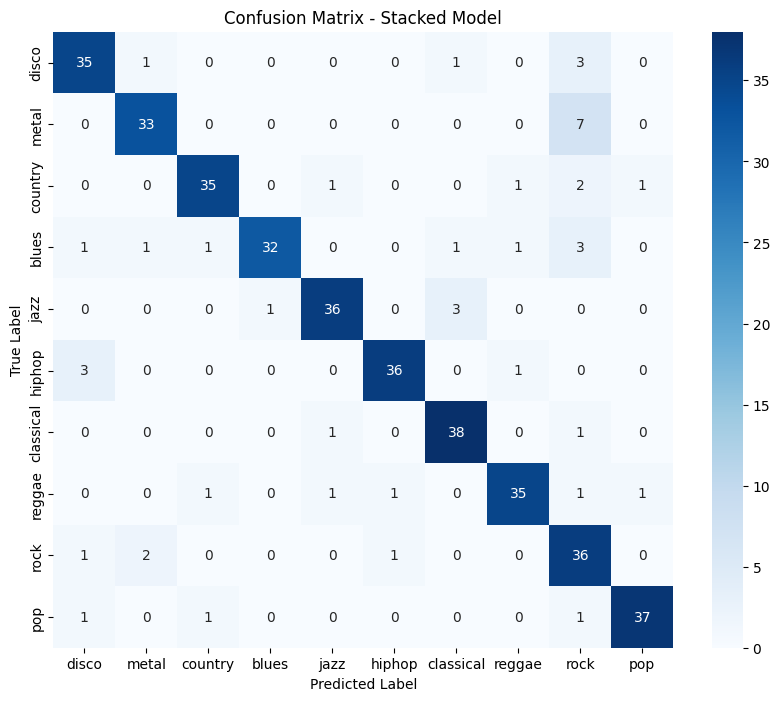

In [108]:
cm = confusion_matrix(y_test, final_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=genres, yticklabels=genres)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Stacked Model')
plt.savefig("Confusion_Matrix.png",dpi = 1200)
plt.show()

In [43]:
import pickle

with open("/content/drive/MyDrive/Genre-prediction/stacked_model.pkl", 'rb') as f:
    stacked1_model = pickle.load(f)

Testing Purposes

In [44]:
import pyspark
import pandas as pd
import librosa as lb
import soundfile as sf
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import scipy.stats
from tqdm import tqdm
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import lightgbm as lgb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input


In [76]:
# filename = "/content/drive/MyDrive/Genre-prediction/test.wav"
filename = "/content/test.wav"
y, sr = lb.load(filename)
time_start_seconds = 15
time_end_seconds = 30

time_start_samples = int(time_start_seconds * sr)
time_end_samples = int(time_end_seconds * sr)

y = y[time_start_samples: time_end_samples]

In [77]:
sr

22050

In [78]:
n_mfccs = 20
n_mels = 8
n_chroma = 12

def mfccFeature(y, sr):
    mfcc_feature = lb.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfccs)
    mfcc_stats = []
    for mfcc in mfcc_feature:
      mfcc_stats.append(np.mean(mfcc))
      mfcc_stats.append(np.var(mfcc))
    return mfcc_stats

def melspectrogramFeature(y, sr):
    fmax = min(8000, sr / 2)
    melspec = lb.feature.melspectrogram(y=y, sr=sr*10, n_mels=n_mels, fmax=100000, n_fft=128)
    melspec_stats = []
    for mels in melspec:
      melspec_stats.append(np.mean(mels))
      melspec_stats.append(np.var(mels))
    return melspec_stats

def chromaCqt(y, sr):
    cqt = lb.feature.chroma_cqt(y=y, sr=sr, n_chroma=n_chroma, hop_length=256, bins_per_octave=24)
    cqtStats = []
    for cqtarr in cqt:
      cqtStats.append(np.mean(cqtarr))
      cqtStats.append(np.var(cqtarr))
    return cqtStats

def chromaCens(y, sr):
    cens = lb.feature.chroma_cens(y=y, sr=sr, n_chroma=n_chroma, hop_length=256, bins_per_octave=24)
    censStats = []
    for censarr in cens:
      censStats.append(np.mean(censarr))
      censStats.append(np.var(censarr))
    return censStats

def chromaStft(y, sr):
    stft = lb.feature.chroma_stft(y=y, sr=sr, n_fft=128, n_chroma=n_chroma)
    stftStats = []
    for stftarr in stft:
      stftStats.append(np.mean(stftarr))
      stftStats.append(np.var(stftarr))
    return stftStats

def spectralCentroid(y, sr):
    specCentroid = lb.feature.spectral_centroid(y=y, sr=sr, n_fft=128)
    return [np.mean(specCentroid[0]),np.var(specCentroid[0])]

def spectralBandwidth(y, sr):
    specBandwidth = lb.feature.spectral_bandwidth(y=y, sr=sr, n_fft=128)
    return [np.mean(specBandwidth[0]),np.var(specBandwidth[0])]

def spectralFlatness(y, sr):
    specflatness = lb.feature.spectral_flatness(y=y, n_fft=128)
    return [np.mean(specflatness[0]), np.var(specflatness[0])]

def spectralRolloff(y, sr):
    specRolloff = lb.feature.spectral_rolloff(y=y, sr=sr, roll_percent=0.85, n_fft=128, hop_length=256)
    return [np.mean(specRolloff[0]),np.var(specRolloff[0])]

def rmsFeature(y):
    rms = lb.feature.rms(y=y)
    return [np.mean(rms[0]),np.var(rms[0])]

def tonnetzFeature(y, sr):
    tonnetz = lb.feature.tonnetz(y=y, sr=sr)
    tonnetzStats = []
    for tonnetzarr in tonnetz:
      tonnetzStats.append(np.mean(tonnetzarr))
      tonnetzStats.append(np.var(tonnetzarr))
    return tonnetzStats

def tempoFeature(y, sr):
    prior = scipy.stats.lognorm(s=1.0, scale=120)
    onset_env = lb.onset.onset_strength(y=y, sr=sr)
    tempo = lb.feature.tempo(onset_envelope=onset_env, sr=sr, prior=prior)
    return tempo[0]

def zcr(y):
    zcr = lb.feature.zero_crossing_rate(y)
    return [np.mean(zcr[0]),np.var(zcr[0])]

def getHarmonic(y):
    harm = lb.effects.harmonic(y)
    return [np.mean(harm), np.var(harm)]

In [79]:
mfccColumn = []
for i in range(n_mfccs):
  mfccColumn.append("mfccFeatureMean_"+str(i+1))
  mfccColumn.append("mfccFeatureVar_"+str(i+1))

melColumn = []
for i in range(n_mels):
  melColumn.append("melspectrogramMean_"+str(i+1))
  melColumn.append("melspectrogramVar_"+str(i+1))

chromacqtColumn = []
for i in range(n_chroma):
  chromacqtColumn.append("chromaCQTMean_"+str(i+1))
  chromacqtColumn.append("chromaCQTVar_"+str(i+1))


chromaCENSColumn = []
for i in range(n_chroma):
  chromaCENSColumn.append("chromaCENSMean_"+str(i+1))
  chromaCENSColumn.append("chromaCENSVar_"+str(i+1))


chromastftColumn = []
for i in range(n_chroma):
  chromastftColumn.append("chromaSTFTMean_"+str(i+1))
  chromastftColumn.append("chromaSTFTVar_"+str(i+1))

tonnetzColumn = []
for i in range(6):
  tonnetzColumn.append("tonnetzMean_"+str(i+1))
  tonnetzColumn.append("tonnetzVar_"+str(i+1))

In [80]:
mfccValues = mfccFeature(y, sr)
melspecValues = melspectrogramFeature(y, sr)
cqtValues = chromaCqt(y, sr)
censValues = chromaCens(y, sr)
stftValues = chromaStft(y, sr)
specCentValue = spectralCentroid(y, sr)
specBandValue = spectralBandwidth(y, sr)
specFlatValue = spectralFlatness(y, sr)
specRollValue = spectralRolloff(y, sr)
rmsValue = rmsFeature(y)
tonnetzValues = tonnetzFeature(y, sr)
tempoValue = tempoFeature(y, sr)
zcrValues = zcr(y)
harmonicValues = getHarmonic(y)
Values = [mfccValues + melspecValues + cqtValues + censValues + stftValues + specCentValue + specBandValue + specFlatValue + specRollValue + rmsValue + tonnetzValues + [tempoValue] + zcrValues + harmonicValues]

In [73]:
stacked_model.predict_proba(Values)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


array([[0.00149799, 0.00155571, 0.00186403, 0.00156238, 0.98491045,
        0.00152309, 0.00205167, 0.0015468 , 0.00186174, 0.00162614]])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


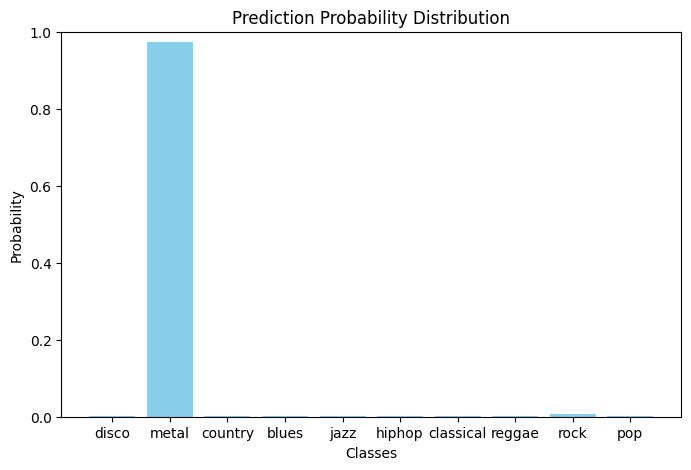

In [81]:
proba = stacked1_model.predict_proba(Values)[0]
class_labels = genres

# Plotting
plt.figure(figsize=(8, 5))
plt.ylim(0, 1)
plt.bar(class_labels, proba, color='skyblue')
plt.xlabel('Classes')
plt.ylabel('Probability')
plt.title('Prediction Probability Distribution')
plt.show()